In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

In [3]:
#set up grids
vals = [0.2 * i for i in range(16)]
xs = [a for a in vals for b in vals]
ys = [b for a in vals for b in vals]

#HSS data from mathematica file
cA = [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., \
0.0102467, 0.0588458, 0.0882836, 0.107703, 0.121405, 0.131574, \
0.139414, 0.145642, 0.150708, 0.15491, 0.158451, 0.161476, 0.164089, \
0.166371, 0.168379, 0.170161, 0.0204934, 0.109539, 0.169663, \
0.210461, 0.239319, 0.260637, 0.276978, 0.289887, 0.300339, 0.308972, \
0.316224, 0.322401, 0.327726, 0.332365, 0.336442, 0.340053, 0.03074, \
0.146042, 0.236777, 0.302462, 0.349571, 0.38422, 0.41054, 0.43114, \
0.44768, 0.461246, 0.472575, 0.482177, 0.490422, 0.497578, 0.50385, \
0.509392, 0.0409867, 0.167162, 0.282793, 0.376363, 0.446486, \
0.498283, 0.537239, 0.567337, 0.591207, 0.61058, 0.626613, 0.640103, \
0.651614, 0.661553, 0.670226, 0.677861, 0.0512334, 0.176854, \
0.305185, 0.424085, 0.522004, 0.596754, 0.652825, 0.69551, 0.728808, \
0.755429, 0.777181, 0.79529, 0.810605, 0.823734, 0.835119, 0.845089, \
0.0614801, 0.180587, 0.309056, 0.441657, 0.566261, 0.670278, \
0.750444, 0.810962, 0.857259, 0.893532, 0.922647, 0.946527, 0.966477, \
0.983406, 0.997963, 1.01062, 0.0717268, 0.182227, 0.303453, 0.435485, \
0.573943, 0.706578, 0.818802, 0.905649, 0.971184, 1.02128, 1.06052, \
1.09205, 1.11793, 1.1396, 1.15801, 1.17387, 0.0819734, 0.183709, \
0.295205, 0.418311, 0.554033, 0.699388, 0.842374, 0.965464, 1.06082, \
1.13233, 1.18666, 1.22905, 1.26302, 1.29089, 1.31421, 1.33403, \
0.0922201, 0.185806, 0.287585, 0.399465, 0.52377, 0.662608, 0.815073, \
0.970549, 1.10793, 1.21445, 1.29338, 1.35265, 1.39852, 1.43509, \
1.46499, 1.48997, 0.102467, 0.188746, 0.281711, 0.38288, 0.494308, \
0.618719, 0.759322, 0.91785, 1.08713, 1.24314, 1.36475, 1.45328, \
1.51856, 1.56843, 1.60784, 1.63991, 0.112713, 0.192535, 0.277774, \
0.369551, 0.469386, 0.579387, 0.70252, 0.842846, 1.00478, 1.18702, \
1.36651, 1.50925, 1.61077, 1.68365, 1.73827, 1.78092, 0.12296, \
0.197097, 0.275634, 0.359381, 0.449411, 0.547186, 0.654764, 0.775144, \
0.912793, 1.07408, 1.26462, 1.47074, 1.64397, 1.76411, 1.84705, \
1.90755, 0.133207, 0.202334, 0.275061, 0.35197, 0.433813, 0.521587, \
0.616645, 0.720905, 0.837192, 0.969888, 1.12605, 1.31631, 1.54469, \
1.76159, 1.91053, 2.00761, 0.143454, 0.208154, 0.275821, 0.346881, \
0.421865, 0.501456, 0.58655, 0.67836, 0.778593, 0.889758, 1.01578, \
1.16322, 1.3439, 1.57681, 1.84691, 2.04485, 0.1537, 0.214471, \
0.277709, 0.343728, 0.41291, 0.485732, 0.562798, 0.644895, 0.733077, \
0.828807, 0.934207, 1.05255, 1.18928, 1.3545, 1.56942, 1.86925]

cP = [0., 0.00144942, 0.00289884, 0.00434826, 0.00579768, 0.0072471, \
0.00869652, 0.0101459, 0.0115954, 0.0130448, 0.0144942, 0.0159436, \
0.017393, 0.0188425, 0.0202919, 0.0217413, 0., 0.00900522, 0.0125011, \
0.0142556, 0.0154203, 0.0163911, 0.017316, 0.0182523, 0.0192212, \
0.0202293, 0.0212766, 0.0223606, 0.023478, 0.0246253, 0.0257993, \
0.0269969, 0., 0.0299371, 0.0407433, 0.0440068, 0.0445253, 0.044109, \
0.0434504, 0.0428185, 0.042314, 0.041968, 0.0417824, 0.0417478, \
0.0418503, 0.0420756, 0.0424099, 0.0428409, 0., 0.0591009, 0.0853272, \
0.0933965, 0.0937411, 0.0912577, 0.0879523, 0.0846156, 0.0815456, \
0.0788382, 0.0765059, 0.0745284, 0.0728734, 0.0715068, 0.0703955, \
0.0695101, 0., 0.089397, 0.140648, 0.160837, 0.163688, 0.159216, \
0.152319, 0.14503, 0.13813, 0.131881, 0.126334, 0.121457, 0.117192, \
0.113472, 0.110234, 0.107419, 0., 0.115342, 0.197246, 0.24086, \
0.253649, 0.249539, 0.238739, 0.22622, 0.213987, 0.20274, 0.192656, \
0.18371, 0.175802, 0.16882, 0.16265, 0.157192, 0., 0.135185, \
0.245849, 0.321896, 0.358145, 0.362452, 0.349841, 0.331298, 0.312007, \
0.293907, 0.277568, 0.263034, 0.250167, 0.238781, 0.228688, 0.21972, \
0., 0.149663, 0.282771, 0.390786, 0.462738, 0.49212, 0.486937, \
0.464212, 0.43642, 0.409138, 0.384216, 0.362026, 0.342425, 0.325126, \
0.309827, 0.296249, 0., 0.160152, 0.309344, 0.442109, 0.54964, \
0.6197, 0.643231, 0.627617, 0.592902, 0.55409, 0.517421, 0.484613, \
0.45575, 0.430434, 0.408176, 0.388525, 0., 0.167838, 0.328342, \
0.478303, 0.612419, 0.721807, 0.79287, 0.812574, 0.785838, 0.736819, \
0.684749, 0.636988, 0.595043, 0.558575, 0.526828, 0.499046, 0., \
0.173575, 0.342132, 0.503807, 0.655635, 0.792668, 0.906305, 0.982014, \
1.00164, 0.963944, 0.897693, 0.829367, 0.76831, 0.715686, 0.670514, \
0.631519, 0., 0.177942, 0.352365, 0.522163, 0.685671, 0.840258, \
0.981508, 1.10156, 1.18596, 1.21168, 1.16552, 1.07845, 0.989623, \
0.912273, 0.846989, 0.79176, 0., 0.181331, 0.360132, 0.53573, \
0.707159, 0.872986, 1.03096, 1.17734, 1.30539, 1.40207, 1.44219, \
1.39542, 1.28397, 1.16828, 1.07032, 0.98971, 0., 0.184006, 0.366153, \
0.546017, 0.723018, 0.89634, 1.06478, 1.2265, 1.37846, 1.51527, \
1.62633, 1.68873, 1.65804, 1.52258, 1.37001, 1.24475, 0., 0.186152, \
0.37091, 0.553998, 0.735056, 0.913599, 1.08895, 1.26014, 1.4257, \
1.58327, 1.72878, 1.85438, 1.94266, 1.94995, 1.80852, 1.60322, 0., \
0.187898, 0.37473, 0.560314, 0.744419, 0.926742, 1.10688, 1.2843, \
1.45822, 1.62751, 1.79041, 1.94396, 2.08274, 2.19518, 2.25103, 2.15837]

mA = [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., \
0.189753, 0.141154, 0.111716, 0.0922971, 0.0785947, 0.0684262, \
0.0605859, 0.0543579, 0.0492917, 0.0450901, 0.0415492, 0.0385244, \
0.0359106, 0.0336292, 0.0316206, 0.0298387, 0.379507, 0.290461, \
0.230337, 0.189539, 0.160681, 0.139363, 0.123022, 0.110113, \
0.0996611, 0.0910278, 0.0837764, 0.0775994, 0.0722741, 0.0676355, \
0.0635584, 0.0599466, 0.56926, 0.453958, 0.363223, 0.297538, \
0.250429, 0.21578, 0.18946, 0.16886, 0.15232, 0.138754, 0.127425, \
0.117823, 0.109578, 0.102422, 0.09615, 0.090608, 0.759013, 0.632838, \
0.517207, 0.423637, 0.353514, 0.301717, 0.262761, 0.232663, 0.208793, \
0.18942, 0.173387, 0.159897, 0.148386, 0.138447, 0.129774, 0.122139, \
0.948767, 0.823146, 0.694815, 0.575915, 0.477996, 0.403246, 0.347175, \
0.30449, 0.271192, 0.244571, 0.222819, 0.20471, 0.189395, 0.176266, \
0.164881, 0.154911, 1.13852, 1.01941, 0.890944, 0.758343, 0.633739, \
0.529722, 0.449556, 0.389038, 0.342741, 0.306468, 0.277353, 0.253473, \
0.233523, 0.216594, 0.202037, 0.189378, 1.32827, 1.21777, 1.09655, \
0.964515, 0.826057, 0.693422, 0.581198, 0.494351, 0.428816, 0.378723, \
0.339477, 0.307953, 0.282065, 0.260404, 0.241991, 0.22613, 1.51803, \
1.41629, 1.30479, 1.18169, 1.04597, 0.900612, 0.757626, 0.634536, \
0.539177, 0.467668, 0.413341, 0.370951, 0.336979, 0.309108, 0.285793, \
0.265966, 1.70778, 1.61419, 1.51242, 1.40053, 1.27623, 1.13739, \
0.984927, 0.829451, 0.692066, 0.585548, 0.506617, 0.447347, 0.401479, \
0.364911, 0.335007, 0.310034, 1.89753, 1.81125, 1.71829, 1.61712, \
1.50569, 1.38128, 1.24068, 1.08215, 0.912874, 0.756857, 0.635247, \
0.546717, 0.481439, 0.431574, 0.392155, 0.360093, 2.08729, 2.00746, \
1.92223, 1.83045, 1.73061, 1.62061, 1.49748, 1.35715, 1.19522, \
1.01298, 0.833488, 0.690749, 0.589225, 0.516349, 0.461727, 0.419075, \
2.27704, 2.2029, 2.12437, 2.04062, 1.95059, 1.85281, 1.74524, \
1.62486, 1.48721, 1.32592, 1.13538, 0.929259, 0.756033, 0.635886, \
0.552946, 0.492454, 2.46679, 2.39767, 2.32494, 2.24803, 2.16619, \
2.07841, 1.98335, 1.8791, 1.76281, 1.63011, 1.47395, 1.28369, \
1.05531, 0.838412, 0.689474, 0.592395, 2.65655, 2.59185, 2.52418, \
2.45312, 2.37814, 2.29854, 2.21345, 2.12164, 2.02141, 1.91024, \
1.78422, 1.63678, 1.4561, 1.22319, 0.953092, 0.755148, 2.8463, \
2.78553, 2.72229, 2.65627, 2.58709, 2.51427, 2.4372, 2.35511, \
2.26692, 2.17119, 2.06579, 1.94745, 1.81072, 1.6455, 1.43058, 1.13075]

mP = [0., 0.198551, 0.397101, 0.595652, 0.794202, 0.992753, 1.1913, \
1.38985, 1.5884, 1.78696, 1.98551, 2.18406, 2.38261, 2.58116, \
2.77971, 2.97826, 0., 0.190995, 0.387499, 0.585744, 0.78458, \
0.983609, 1.18268, 1.38175, 1.58078, 1.77977, 1.97872, 2.17764, \
2.37652, 2.57537, 2.7742, 2.973, 0., 0.170063, 0.359257, 0.555993, \
0.755475, 0.955891, 1.15655, 1.35718, 1.55769, 1.75803, 1.95822, \
2.15825, 2.35815, 2.55792, 2.75759, 2.95716, 0., 0.140899, 0.314673, \
0.506604, 0.706259, 0.908742, 1.11205, 1.31538, 1.51845, 1.72116, \
1.92349, 2.12547, 2.32713, 2.52849, 2.7296, 2.93049, 0., 0.110603, \
0.259352, 0.439163, 0.636312, 0.840784, 1.04768, 1.25497, 1.46187, \
1.66812, 1.87367, 2.07854, 2.28281, 2.48653, 2.68977, 2.89258, 0., \
0.0846582, 0.202754, 0.35914, 0.546351, 0.750461, 0.961261, 1.17378, \
1.38601, 1.59726, 1.80734, 2.01629, 2.2242, 2.43118, 2.63735, \
2.84281, 0., 0.064815, 0.154151, 0.278104, 0.441855, 0.637548, \
0.850159, 1.0687, 1.28799, 1.50609, 1.72243, 1.93697, 2.14983, \
2.36122, 2.57131, 2.78028, 0., 0.0503367, 0.117229, 0.209214, \
0.337262, 0.50788, 0.713063, 0.935788, 1.16358, 1.39086, 1.61578, \
1.83797, 2.05758, 2.27487, 2.49017, 2.70375, 0., 0.0398481, \
0.0906561, 0.157891, 0.25036, 0.3803, 0.556769, 0.772383, 1.0071, \
1.24591, 1.48258, 1.71539, 1.94425, 2.16957, 2.39182, 2.61148, 0., \
0.0321619, 0.0716576, 0.121697, 0.187581, 0.278193, 0.40713, \
0.587426, 0.814162, 1.06318, 1.31525, 1.56301, 1.80496, 2.04142, \
2.27317, 2.50095, 0., 0.026425, 0.0578676, 0.0961931, 0.144365, \
0.207332, 0.293695, 0.417986, 0.59836, 0.836056, 1.10231, 1.37063, \
1.63169, 1.88431, 2.12949, 2.36848, 0., 0.0220577, 0.0476349, \
0.0778373, 0.114329, 0.159742, 0.218492, 0.298442, 0.414038, \
0.588319, 0.83448, 1.12155, 1.41038, 1.68773, 1.95301, 2.20824, 0., \
0.0186691, 0.0398678, 0.0642705, 0.0928409, 0.127014, 0.169038, \
0.22266, 0.294612, 0.397928, 0.557809, 0.80458, 1.11603, 1.43172, \
1.72968, 2.01029, 0., 0.0159937, 0.0338467, 0.0539831, 0.0769821, \
0.10366, 0.135216, 0.173497, 0.221537, 0.284728, 0.373667, 0.511268, \
0.741965, 1.07742, 1.42999, 1.75525, 0., 0.0138479, 0.0290904, \
0.0460021, 0.0649437, 0.0864012, 0.111049, 0.13986, 0.174302, \
0.216728, 0.271215, 0.345618, 0.457336, 0.650051, 0.991478, 1.39678, \
0., 0.0121024, 0.02527, 0.0396855, 0.0555812, 0.073258, 0.0931156, \
0.115699, 0.141779, 0.172489, 0.209593, 0.256039, 0.317262, 0.404818, \
0.548975, 0.841635]

xs = np.array(xs)
ys = np.array(ys)

DcA = 1.5
DcP = 1.5
DmA = 0.28
DmP = 1



Calculating the local mass redistribustion potential

In [4]:
N=len(mP)

fs = np.zeros(N)
gs = np.zeros(N)

for i in range(N):
    fs[i] = cA[i] + (DmA / DcA) * mA[i]
    gs[i] = cP[i] + (DmP / DcP) * mP[i]

fs = np.array(fs)
gs = np.array(gs)

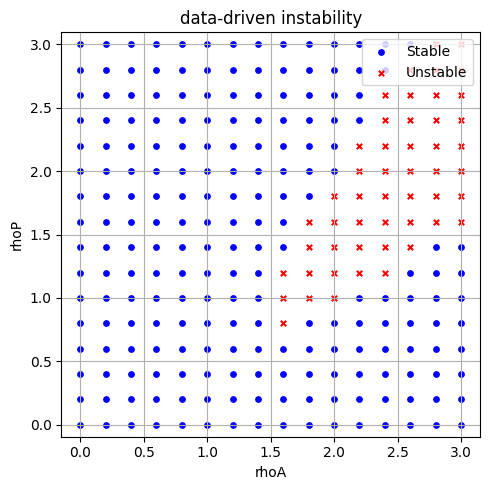

In [6]:
# --- KD-tree for nearest neighbors
tree = cKDTree(np.column_stack((xs, ys)))
k = 4  # neighbors (excluding self)

N = len(xs)
fx = np.zeros(N)
fy = np.zeros(N)
gx = np.zeros(N)
gy = np.zeros(N)

for i in range(N):
    idx = tree.query([xs[i], ys[i]], k=k+1)[1][1:]  # skip self
    dx = xs[idx] - xs[i]
    dy = ys[idx] - ys[i]
    df = fs[idx] - fs[i]
    dg = gs[idx] - gs[i]
    A = np.stack([dx, dy], axis=1)
    fx[i], fy[i] = np.linalg.lstsq(A, df, rcond=None)[0]
    gx[i], gy[i] = np.linalg.lstsq(A, dg, rcond=None)[0]

# --- Trace and determinant
trace = fx + gy
det = fx * gy - fy * gx
unstable_mask = (trace < 0) | (det < 0)

# --- Interpolate mask to a grid
grid_x, grid_y = np.mgrid[0:3:50j, 0:3:50j]
mask_float = unstable_mask.astype(float)
interp_mask = griddata((xs, ys), mask_float, (grid_x, grid_y), method='cubic', fill_value=0)

# --- Smooth the interpolated mask
smoothed = gaussian_filter(interp_mask, sigma=2)

# --- Plot
plt.figure(figsize=(5, 5))
plt.title("data-driven instability")

# Scatter plot
plt.scatter(xs[~unstable_mask], ys[~unstable_mask], color='blue', s=15, label='Stable')
plt.scatter(xs[unstable_mask], ys[unstable_mask], color='red', s=15, label='Unstable', marker='x')


plt.xlabel('rhoA')
plt.ylabel('rhoP')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()